## 0. Cài đặt & Import

In [37]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kaggle", "seaborn", "tf2onnx", "onnx"], check=False)

import os, json, shutil, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from pathlib import Path
from PIL import Image

warnings.filterwarnings('ignore')
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU: []


In [38]:
from google.colab import drive, files
drive.mount('/content/drive')
print('✅ Drive mounted')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted


In [39]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_6f24585f9e2ea641562b96d0a0074889'

In [40]:
# Tải dataset tiền Việt Nam (11 mệnh giá, ~2750 ảnh)
!kaggle datasets download -d nguyentrongdai/vietnamese-currency -p /content/vnd_raw --unzip

# Xem cấu trúc dataset
import os
RAW_DIR = '/content/vnd_raw/dataset'
classes = sorted([d for d in os.listdir(RAW_DIR) if os.path.isdir(os.path.join(RAW_DIR, d))])
print(f'\n📦 Tìm thấy {len(classes)} class:')
for i, c in enumerate(classes):
    n = len(os.listdir(os.path.join(RAW_DIR, c)))
    print(f'  {i:2d}. {c:<20} {n} ảnh')

Dataset URL: https://www.kaggle.com/datasets/nguyentrongdai/vietnamese-currency
License(s): unknown
100% 238M/238M [00:02<00:00, 105MB/s] 


📦 Tìm thấy 12 class:
   0. 000000               250 ảnh
   1. 000200               250 ảnh
   2. 000500               250 ảnh
   3. 001000               250 ảnh
   4. 002000               250 ảnh
   5. 005000               154 ảnh
   6. 010000               250 ảnh
   7. 020000               154 ảnh
   8. 050000               154 ảnh
   9. 100000               250 ảnh
  10. 200000               250 ảnh
  11. 500000               250 ảnh


In [41]:
import cv2
import numpy as np
from PIL import Image
from pathlib import Path

def crop_banknote(pil_img, padding=15):
    """Dùng Canny edge detection để tìm & crop vùng tờ tiền lớn nhất."""
    img_bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur    = cv2.GaussianBlur(gray, (5, 5), 0)
    edged   = cv2.Canny(blur, 30, 150)

    contours, _ = cv2.findContours(edged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    H, W = img_bgr.shape[:2]

    if contours:
        largest = max(contours, key=cv2.contourArea)
        if cv2.contourArea(largest) > W * H * 0.08:  # ít nhất 8% diện tích
            x, y, w, h = cv2.boundingRect(largest)
            x1 = max(0, x - padding)
            y1 = max(0, y - padding)
            x2 = min(W, x + w + padding)
            y2 = min(H, y + h + padding)
            return pil_img.crop((x1, y1, x2, y2))
    return pil_img  # fallback: ảnh gốc


def preprocess_dataset(src_dir, dst_dir, target_size=(128, 128)):
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)
    total, cropped, fallback, err = 0, 0, 0, 0

    for img_path in src_dir.rglob('*'):
        if img_path.suffix.lower() not in ['.jpg', '.jpeg', '.png', '.bmp']:
            continue

        out_path = dst_dir / img_path.relative_to(src_dir)
        out_path.parent.mkdir(parents=True, exist_ok=True)

        try:
            pil_img = Image.open(str(img_path)).convert('RGB')
            original_size = pil_img.size
            pil_img = crop_banknote(pil_img)

            if pil_img.size != original_size:
                cropped += 1
            else:
                fallback += 1

            pil_img.resize(target_size, Image.LANCZOS).save(str(out_path))
            total += 1
        except Exception as e:
            print(f'  ❌ {img_path.name}: {e}')
            err += 1

    print(f'\n✅ Tiền xử lý xong!')
    print(f'   Tổng ảnh    : {total}')
    print(f'   Crop được   : {cropped}')
    print(f'   Fallback    : {fallback}')
    print(f'   Lỗi         : {err}')


PROCESSED_DIR = '/content/vnd_processed'
preprocess_dataset(RAW_DIR, PROCESSED_DIR, target_size=(112, 224))


✅ Tiền xử lý xong!
   Tổng ảnh    : 2712
   Crop được   : 35
   Fallback    : 2677
   Lỗi         : 0


## 1. Siêu tham số

In [42]:
# ════════════════════════════════════════════════
# SIÊU THAM SỐ — chỉnh tại đây
# ════════════════════════════════════════════════
IMG_W          = 224      # width  (tỉ lệ 2:1 tờ tiền)
IMG_H          = 112      # height
IMG_SIZE       = (IMG_H, IMG_W)   # Keras dùng (H, W)
BATCH_SIZE     = 32
SEED           = 42
VAL_SPLIT      = 0.20     # 20% validation
EPOCHS_P1      = 20       # Phase 1: base frozen
EPOCHS_P2      = 20       # Phase 2: fine-tune
FINE_TUNE_AT   = 100      # unfreeze từ layer này trở đi
LR_P1          = 1e-3
LR_P2          = 1e-4     # LR nhỏ hơn khi fine-tune
AUTOTUNE       = tf.data.AUTOTUNE

PROCESSED_DIR = '/content/vnd_processed/dataset'
TRAIN_DIR     = os.path.join(PROCESSED_DIR, 'train')
VAL_DIR       = os.path.join(PROCESSED_DIR, 'val')
RAW_DIR       = '/content/vnd_raw/dataset'
OUTPUT_DIR    = '/content/output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Config OK")
print(f"  IMG: {IMG_W}x{IMG_H} (ratio {IMG_W/IMG_H:.1f}:1)")
print(f"  Batch: {BATCH_SIZE} | Val split: {VAL_SPLIT*100:.0f}%")


Config OK
  IMG: 224x112 (ratio 2.0:1)
  Batch: 32 | Val split: 20%


## 2. Khám phá dataset


 12 class:
  000000        250 ảnh  █████████████████████████
  000200        250 ảnh  █████████████████████████
  000500        250 ảnh  █████████████████████████
  001000        250 ảnh  █████████████████████████
  002000        250 ảnh  █████████████████████████
  005000        154 ảnh  ███████████████
  010000        250 ảnh  █████████████████████████
  020000        154 ảnh  ███████████████
  050000        154 ảnh  ███████████████
  100000        250 ảnh  █████████████████████████
  200000        250 ảnh  █████████████████████████
  500000        250 ảnh  █████████████████████████

Tổng: 2712 ảnh


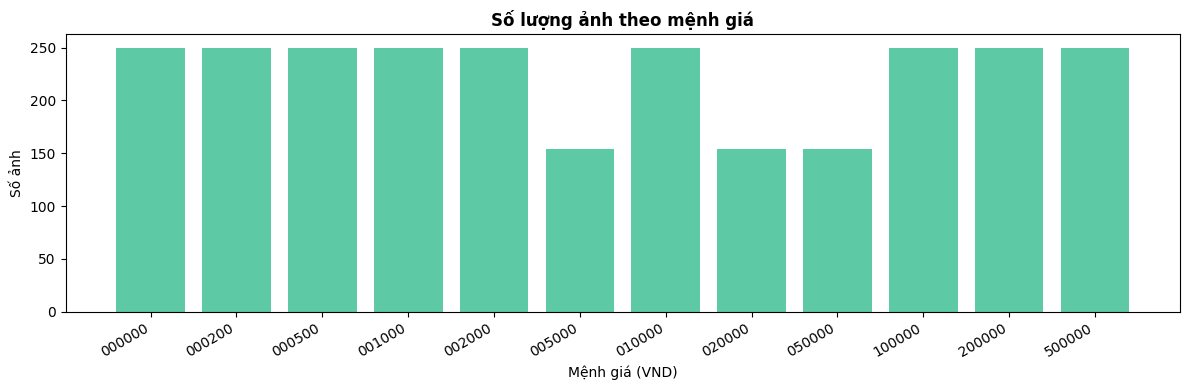

In [43]:
# Xem cấu trúc dataset Kaggle
classes = sorted([d for d in os.listdir(RAW_DIR) if os.path.isdir(os.path.join(RAW_DIR, d))])
print(f"\n {len(classes)} class:")
total_imgs = 0
data_info = {}
for c in classes:
    n = len([f for f in os.listdir(os.path.join(RAW_DIR, c))
             if f.lower().endswith(('.jpg','.jpeg','.png'))])
    data_info[c] = n
    total_imgs += n
    bar = '█' * (n // 10)
    print(f"  {c:<12} {n:4d} ảnh  {bar}")
print(f"\nTổng: {total_imgs} ảnh")

# Bar chart
plt.figure(figsize=(12, 4))
plt.bar(data_info.keys(), data_info.values(), color='#5DCAA5', edgecolor='none')
plt.title('Số lượng ảnh theo mệnh giá', fontweight='bold')
plt.xlabel('Mệnh giá (VND)'); plt.ylabel('Số ảnh')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()


In [44]:
# Hiển thị ảnh mẫu mỗi class
import glob, matplotlib.image as mpimg

plt.figure(figsize=(20, 10))
for i, cls in enumerate(classes[:12]):
    cls_dir = os.path.join(RAW_DIR, cls)
    imgs = glob.glob(os.path.join(cls_dir, '*.jpg')) + glob.glob(os.path.join(cls_dir, '*.jpeg'))
    if imgs:
        img = mpimg.imread(random.choice(imgs))
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        plt.title(f"{cls} VND", fontsize=9)
        h, w = img.shape[:2]
        ax.set_xlabel(f"{w}x{h}", fontsize=8)
        plt.axis('off')
plt.suptitle('Ảnh mẫu từ dataset', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


<Figure size 2000x1000 with 0 Axes>

## 3. Tiền xử lý — Crop 2:1 & Chia train/val

In [45]:
from imutils import paths

def crop_21(pil_img: Image.Image, out_w=IMG_W, out_h=IMG_H) -> Image.Image:
    """
    Crop ảnh về tỉ lệ 2:1 (width:height) rồi resize.
    Giữ vùng trung tâm, loại bỏ phần thừa trên/dưới hoặc trái/phải.
    """
    w, h = pil_img.size
    target = out_w / out_h  # 2.0
    current = w / h

    if abs(current - target) < 0.05:
        pass  # đã đúng tỉ lệ
    elif current < target:
        new_h = int(w / target)
        top = (h - new_h) // 2
        pil_img = pil_img.crop((0, top, w, top + new_h))
    else:
        new_w = int(h * target)
        left = (w - new_w) // 2
        pil_img = pil_img.crop((left, 0, left + new_w, h))

    return pil_img.resize((out_w, out_h), Image.LANCZOS)


def split_and_preprocess(raw_dir, train_dir, val_dir, val_ratio=VAL_SPLIT, seed=SEED):
    all_paths = list(paths.list_images(raw_dir))
    random.seed(seed)
    random.shuffle(all_paths)

    n_val        = int(len(all_paths) * val_ratio)
    train_paths  = all_paths[n_val:]
    val_paths    = all_paths[:n_val]

    shutil.rmtree(train_dir, ignore_errors=True)
    shutil.rmtree(val_dir,   ignore_errors=True)

    for phase, img_paths, out_dir in [
        ('Train', train_paths, train_dir),
        ('Val',   val_paths,   val_dir)
    ]:
        total, err = 0, 0
        for p in img_paths:
            label   = Path(p).parent.name
            out_cls = os.path.join(out_dir, label)
            os.makedirs(out_cls, exist_ok=True)
            try:
                pil = Image.open(p).convert('RGB')
                crop_21(pil).save(os.path.join(out_cls, Path(p).name), quality=92)
                total += 1
            except Exception as e:
                err += 1
        print(f"  {phase}: {total} ảnh | Lỗi: {err}")

print("Đang tiền xử lý...")
split_and_preprocess(RAW_DIR, TRAIN_DIR, VAL_DIR)
print("✅ Xong!")


Đang tiền xử lý...
  Train: 2170 ảnh | Lỗi: 0
  Val: 542 ảnh | Lỗi: 0
✅ Xong!


        Train  Val  Total
500000    199   51    250
200000    196   54    250
000200    205   45    250
020000    126   28    154
000000    208   42    250
010000    204   46    250
000500    203   47    250
002000    200   50    250
100000    195   55    250
050000    123   31    154
005000    117   37    154
001000    194   56    250

Tổng Train: 2170 | Val: 542


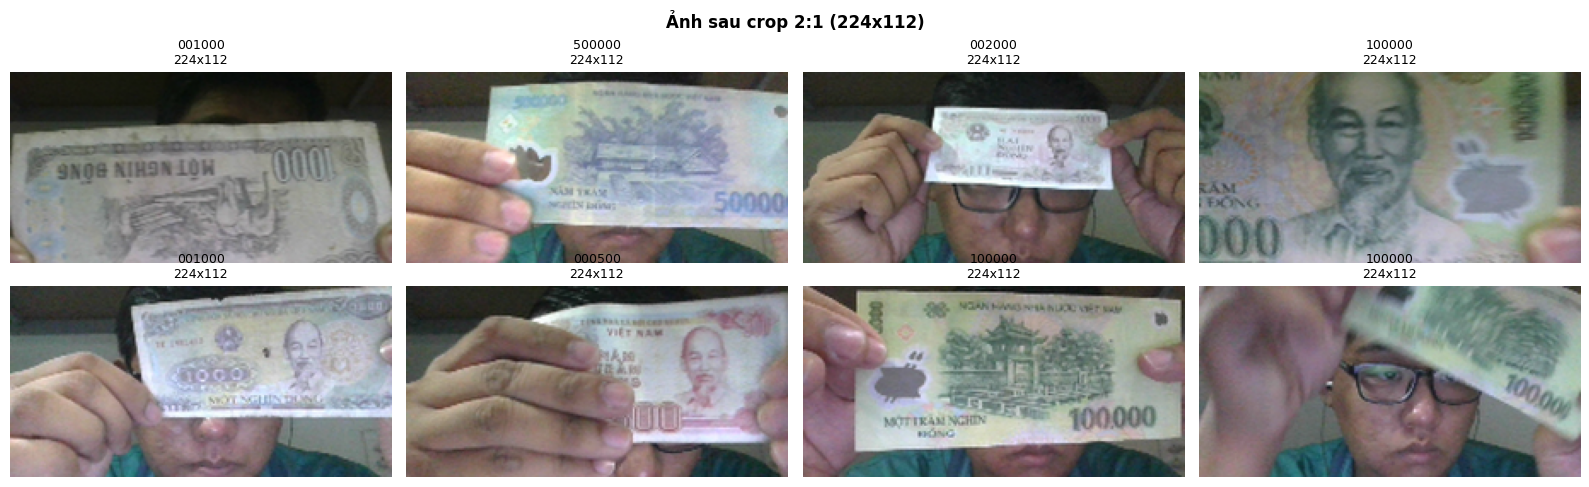

In [46]:
# Kiểm tra phân phối sau khi chia
train_counts = {c: len(list(paths.list_images(os.path.join(TRAIN_DIR, c))))
                for c in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, c))}
val_counts   = {c: len(list(paths.list_images(os.path.join(VAL_DIR, c))))
                for c in os.listdir(VAL_DIR)   if os.path.isdir(os.path.join(VAL_DIR, c))}

df = pd.DataFrame({'Train': train_counts, 'Val': val_counts}).fillna(0).astype(int)
df['Total'] = df['Train'] + df['Val']
print(df.to_string())
print(f"\nTổng Train: {df['Train'].sum()} | Val: {df['Val'].sum()}")

# Xem ảnh đã crop 2:1
sample_paths = random.sample(list(paths.list_images(TRAIN_DIR)), 8)
fig, axes = plt.subplots(2, 4, figsize=(16, 5))
for ax, p in zip(axes.flat, sample_paths):
    img = Image.open(p)
    ax.imshow(img)
    ax.set_title(f"{Path(p).parent.name}\n{img.size[0]}x{img.size[1]}", fontsize=9)
    ax.axis('off')
plt.suptitle(f'Ảnh sau crop 2:1 ({IMG_W}x{IMG_H})', fontweight='bold')
plt.tight_layout(); plt.show()


## 4. Data Pipeline — tf.data + Augmentation


In [47]:

train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range         = 15,
    zoom_range             = 0.10,
    width_shift_range      = 0.10,
    height_shift_range     = 0.10,
    horizontal_flip        = True,
    brightness_range       = [0.75, 1.25],
    fill_mode              = 'nearest'
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True,  color_mode='rgb'
)
val_gen = val_datagen.flow_from_directory(
    VAL_DIR,   target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, color_mode='rgb'
)

NUM_CLASSES  = len(train_gen.class_indices)
CLASS_NAMES  = sorted(train_gen.class_indices, key=train_gen.class_indices.get)
NUM_TRAIN    = len(list(paths.list_images(TRAIN_DIR)))
NUM_VAL      = len(list(paths.list_images(VAL_DIR)))

print(f"Classes ({NUM_CLASSES}):", CLASS_NAMES)
print(f"Train: {NUM_TRAIN} | Val: {NUM_VAL}")


Found 2170 images belonging to 12 classes.
Found 542 images belonging to 12 classes.
Classes (12): ['000000', '000200', '000500', '001000', '002000', '005000', '010000', '020000', '050000', '100000', '200000', '500000']
Train: 2170 | Val: 542


In [48]:

def preprocess_tf(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

def augment_tf(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.15)
    image = tf.image.random_contrast(image, 0.85, 1.15)
    return image, label

train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR, seed=SEED, image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, label_mode='categorical'
)
val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR, seed=SEED, image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, label_mode='categorical', shuffle=False
)


train_ds = (train_ds_raw
            .map(augment_tf,     num_parallel_calls=AUTOTUNE)
            .map(preprocess_tf,  num_parallel_calls=AUTOTUNE)
            .shuffle(1000, seed=SEED)
            .prefetch(AUTOTUNE))

val_ds = (val_ds_raw
          .map(preprocess_tf, num_parallel_calls=AUTOTUNE)
          .prefetch(AUTOTUNE))

print("✅ tf.data pipeline sẵn sàng")


Found 2170 files belonging to 12 classes.
Found 542 files belonging to 12 classes.
✅ tf.data pipeline sẵn sàng


## 5. Lưu class_names.json & labels.txt cho GUI


In [49]:

class_indices = dict(train_gen.class_indices)

json_path = os.path.join(OUTPUT_DIR, 'class_names.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(class_indices, f, ensure_ascii=False, indent=2)

# labels.txt — tương thích File 1
labels_path = os.path.join(OUTPUT_DIR, 'labels.txt')
with open(labels_path, 'w') as f:
    f.write('\n'.join(CLASS_NAMES))

print("✅ Lưu xong:")
print(f"   {json_path}")
print(f"   {labels_path}")
print(f"\nMapping: {class_indices}")


✅ Lưu xong:
   /content/output/class_names.json
   /content/output/labels.txt

Mapping: {'000000': 0, '000200': 1, '000500': 2, '001000': 3, '002000': 4, '005000': 5, '010000': 6, '020000': 7, '050000': 8, '100000': 9, '200000': 10, '500000': 11}


## 6. Build Model — MobileNetV2

In [50]:
def build_model(num_classes, img_h=IMG_H, img_w=IMG_W, lr=LR_P1):
    base = MobileNetV2(
        input_shape = (img_h, img_w, 3),
        include_top = False,
        weights     = 'imagenet'
    )
    base.trainable = False   # Phase 1: đóng băng toàn bộ

    inputs = layers.Input(shape=(img_h, img_w, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, output, name='VND_MobileNetV2')
    model.compile(
        optimizer = keras.optimizers.Adam(lr),
        loss      = 'categorical_crossentropy',
        metrics   = ['accuracy']
    )
    return model

model = build_model(NUM_CLASSES)
model.summary()
print(f"\nTotal params: {model.count_params():,}")


Model: "VND_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 112, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,148 (9.90 MB)

 Trainable params: 334,092 (1.27 MB)

 Non-trainable params: 2,261,056 (8.63 MB)


Total params: 2,595,148


## 7. Train Phase 1 — Base Frozen

In [51]:
CKPT_PATH = os.path.join(OUTPUT_DIR, 'best_checkpoint.weights.h5')

callbacks_p1 = [
    keras.callbacks.ModelCheckpoint(
        filepath=CKPT_PATH, save_weights_only=True,
        monitor='val_accuracy', mode='max', save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=6,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        min_lr=1e-7, verbose=1
    )
]

print("=== Phase 1: Feature Extraction (base frozen) ===")
start = time.time()
history_p1 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS_P1,
    callbacks       = callbacks_p1
)
print(f"\n⏱ Phase 1: {time.time()-start:.0f}s")
print(f"Best val_accuracy: {max(history_p1.history['val_accuracy'])*100:.2f}%")


=== Phase 1: Feature Extraction (base frozen) ===
Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - accuracy: 0.3773 - loss: 2.1941
Epoch 1: val_accuracy improved from None to 0.78967, saving model to /content/output/best_checkpoint.weights.h5

Epoch 1: finished saving model to /content/output/best_checkpoint.weights.h5
68/68 ━━━━━━━━━━━━━━━━━━━━ 114s 890ms/step - accuracy: 0.5406 - loss: 1.5264 - val_accuracy: 0.7897 - val_loss: 0.7176 - learning_rate: 0.0010
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.8076 - loss: 0.6018
Epoch 2: val_accuracy improved from 0.78967 to 0.86716, saving model to /content/output/best_checkpoint.weights.h5

Epoch 2: finished saving model to /content/output/best_checkpoint.weights.h5
68/68 ━━━━━━━━━━━━━━━━━━━━ 87s 985ms/step - accuracy: 0.8101 - loss: 0.5860 - val_accuracy: 0.8672 - val_loss: 0.4544 - learning_rate: 0.0010
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.8553 - loss: 0.4282
Epoch 3: val_accuracy im

## 8. Train Phase 2 — Fine-tune (từ File 2)

In [52]:
base_model = model.layers[1]   # MobileNetV2 là layer index 1
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

n_trainable = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers: {n_trainable}")

model.compile(
    optimizer = keras.optimizers.Adam(LR_P2),   # LR nhỏ hơn
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks_p2 = [
    keras.callbacks.ModelCheckpoint(
        filepath=CKPT_PATH, save_weights_only=True,
        monitor='val_accuracy', mode='max', save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4,
        min_lr=1e-8, verbose=1
    )
]

print("\n=== Phase 2: Fine-tuning ===")
start = time.time()
history_p2 = model.fit(
    train_ds,
    validation_data  = val_ds,
    epochs           = EPOCHS_P1 + EPOCHS_P2,
    initial_epoch    = len(history_p1.history['loss']),  # tiếp tục từ phase 1
    callbacks        = callbacks_p2
)
print(f"\n⏱ Phase 2: {time.time()-start:.0f}s")
print(f"Best val_accuracy: {max(history_p2.history['val_accuracy'])*100:.2f}%")
model.load_weights(CKPT_PATH)


Trainable layers: 9

=== Phase 2: Fine-tuning ===
Epoch 19/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7817 - loss: 0.6830
Epoch 19: val_accuracy improved from None to 0.88930, saving model to /content/output/best_checkpoint.weights.h5

Epoch 19: finished saving model to /content/output/best_checkpoint.weights.h5
68/68 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.8134 - loss: 0.5838 - val_accuracy: 0.8893 - val_loss: 0.4453 - learning_rate: 1.0000e-04
Epoch 20/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9212 - loss: 0.2484
Epoch 20: val_accuracy did not improve from 0.88930
68/68 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.9359 - loss: 0.2087 - val_accuracy: 0.8819 - val_loss: 0.4203 - learning_rate: 1.0000e-04
Epoch 21/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9512 - loss: 0.1329
Epoch 21: val_accuracy did not improve from 0.88930
68/68 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.9539 - loss: 0.1308 - val_accuracy: 0.8727 - val_loss: 0.449

## 9. Vẽ biểu đồ (kết hợp cả 2 phase như File 2)

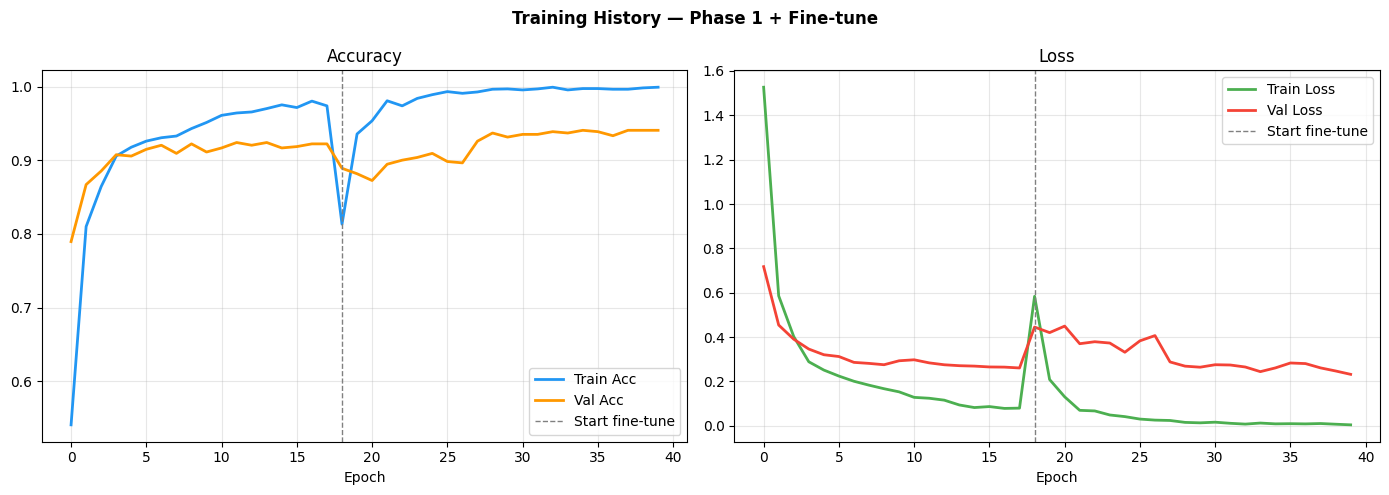

In [53]:
# Nối 2 phase lại — kỹ thuật từ File 2
acc      = history_p1.history['accuracy']     + history_p2.history['accuracy']
val_acc  = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
loss     = history_p1.history['loss']         + history_p2.history['loss']
val_loss = history_p1.history['val_loss']     + history_p2.history['val_loss']
split_ep = len(history_p1.history['loss'])    # điểm chia 2 phase

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc,     label='Train Acc',  lw=2, color='#2196F3')
plt.plot(val_acc, label='Val Acc',    lw=2, color='#FF9800')
plt.axvline(split_ep, color='gray', ls='--', lw=1, label='Start fine-tune')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(loss,     label='Train Loss', lw=2, color='#4CAF50')
plt.plot(val_loss, label='Val Loss',   lw=2, color='#F44336')
plt.axvline(split_ep, color='gray', ls='--', lw=1, label='Start fine-tune')
plt.title('Loss'); plt.xlabel('Epoch'); plt.legend(); plt.grid(alpha=0.3)

plt.suptitle('Training History — Phase 1 + Fine-tune', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_history.png'), dpi=150)
plt.show()


## 13. Lưu model .h5

In [54]:
# Rebuild model để save full model (không chỉ weights)
final_model = build_model(NUM_CLASSES)
final_model.load_weights(CKPT_PATH)

MODEL_H5 = os.path.join(OUTPUT_DIR, 'vnd_model.h5')
final_model.save(MODEL_H5)
print(f"✅ Model saved: {MODEL_H5}")
print(f"   Size: {os.path.getsize(MODEL_H5)/1e6:.1f} MB")

# Đánh giá lần cuối
val_gen.reset()
result = final_model.evaluate(val_gen, verbose=1)
print(f"\n🎯 Final val accuracy: {result[1]*100:.2f}%")


✅ Model saved: /content/output/vnd_model.h5
   Size: 10.8 MB
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 772ms/step - accuracy: 0.9410 - loss: 0.2611

🎯 Final val accuracy: 94.10%


## 15. Test nhận diện ảnh đơn lẻ


🖼  010000_28.png
─────────────────────────────────────────────
✅ 1. 010000         100.00%  ███████████████████
   2. 100000           0.00%  
   3. 200000           0.00%  


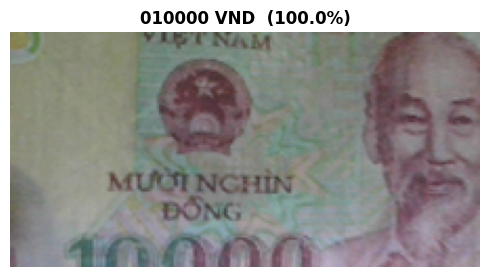


🖼  000200_186.png
─────────────────────────────────────────────
✅ 1. 000200          93.45%  ██████████████████
   2. 000500           4.95%  
   3. 002000           0.74%  


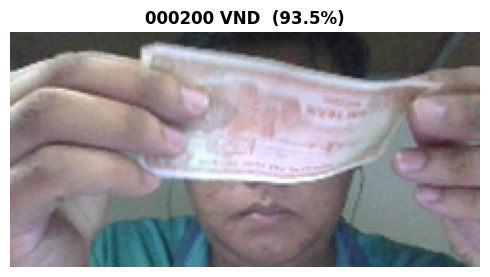


🖼  500000_45.png
─────────────────────────────────────────────
✅ 1. 500000          99.89%  ███████████████████
   2. 010000           0.08%  
   3. 200000           0.02%  


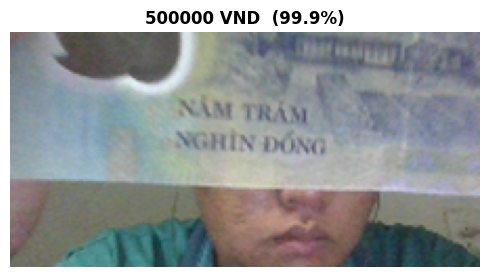


🖼  000500_106.png
─────────────────────────────────────────────
✅ 1. 000000          92.77%  ██████████████████
   2. 000500           3.69%  
   3. 200000           2.70%  


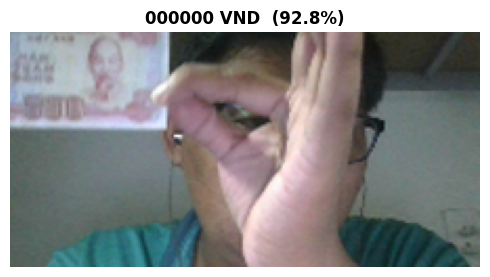

In [55]:
def predict_single(img_path, model, class_names, img_size=IMG_SIZE):
    idx_to_class = {i: n for i, n in enumerate(class_names)}

    pil = Image.open(img_path).convert('RGB')
    w, h = pil.size
    target = img_size[1] / img_size[0]
    if w / h < target:
        new_h = int(w / target)
        pil = pil.crop((0, (h-new_h)//2, w, (h-new_h)//2 + new_h))
    elif w / h > target:
        new_w = int(h * target)
        pil = pil.crop(((w-new_w)//2, 0, (w-new_w)//2 + new_w, h))
    pil = pil.resize((img_size[1], img_size[0]), Image.LANCZOS)

    arr = np.array(pil, dtype=np.float32)
    arr = preprocess_input(arr)
    arr = np.expand_dims(arr, 0)

    preds = model.predict(arr, verbose=0)[0]
    top3  = np.argsort(preds)[::-1][:3]

    print(f"\n🖼  {Path(img_path).name}")
    print("─" * 45)
    for i, idx in enumerate(top3):
        name = idx_to_class[idx]
        conf = preds[idx] * 100
        bar  = '█' * int(conf / 5)
        mark = '✅' if i == 0 else '  '
        print(f"{mark} {i+1}. {name:<14} {conf:6.2f}%  {bar}")

    plt.figure(figsize=(5, 3))
    plt.imshow(pil)
    best = idx_to_class[top3[0]]
    plt.title(f"{best} VND  ({preds[top3[0]]*100:.1f}%)", fontweight='bold')
    plt.axis('off'); plt.tight_layout(); plt.show()

# Test 4 ảnh từ val set
test_imgs = random.sample(list(paths.list_images(VAL_DIR)), 4)
for p in test_imgs:
    predict_single(p, final_model, CLASS_NAMES)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


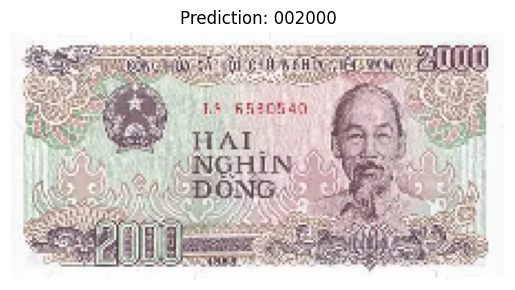

Predicted class: 002000
Confidence: 0.9998191


In [56]:
import numpy as np
import matplotlib.pyplot as plt
from keras.utils import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input # Import preprocess_input

# Load ảnh
img_path = "/content/OIP.webp"
img = load_img(img_path, target_size=IMG_SIZE) # Use IMG_SIZE (112, 224) as defined
img_array = img_to_array(img)

# Apply MobileNetV2 preprocessing
img_processed = preprocess_input(img_array.astype("float32"))

# Reshape for model (add batch dimension)
input_img = np.expand_dims(img_processed, axis=0)

# Predict
pred = model.predict(input_img)

# Lấy class index
pred_class = np.argmax(pred, axis=-1)[0]

# Nếu có class_names
class_labels = {v:k for k,v in train_gen.class_indices.items()}
pred_name = class_labels[pred_class]
# Hiển thị ảnh (using the original img for display before preprocessing)
plt.imshow(img)
plt.title(f"Prediction: {pred_name}")
plt.axis("off")
plt.show()

print("Predicted class:", pred_name)
print("Confidence:", np.max(pred))

In [57]:
files.download('/content/output/vnd_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>